In [ ]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

In [20]:
df_new= pd.read_csv('/content/Teen_Mental_Health_Dataset.csv')

In [5]:
#ilk beş satır yaazdırma
df_new.head()# parantez içine değer vermezsen default beş satır yazdırır

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.90,Instagram,7.40,2.90,3.01,1.50,low,2,2,1,0
1,19,female,1.90,TikTok,8.00,2.90,3.22,0.80,high,8,1,10,0
2,17,female,1.30,Instagram,7.60,0.50,3.92,0.00,high,2,4,2,0
3,15,male,7.40,TikTok,6.90,1.60,3.48,0.80,medium,1,7,9,0
4,15,female,4.70,Both,4.90,3.00,2.37,1.40,medium,3,5,2,0


In [6]:
df_new.head(3)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.90,Instagram,7.40,2.90,3.01,1.50,low,2,2,1,0
1,19,female,1.90,TikTok,8.00,2.90,3.22,0.80,high,8,1,10,0
2,17,female,1.30,Instagram,7.60,0.50,3.92,0.00,high,2,4,2,0


In [7]:
# son 5 satırı bastırıyor
df_new.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.80,Instagram,6.60,2.00,2.76,1.00,low,3,4,4,0
1196,16,male,2.30,Both,8.00,1.90,2.12,0.40,high,7,4,4,0
1197,14,female,1.70,Both,8.70,0.70,3.98,0.80,high,1,1,1,0
1198,15,male,3.90,Both,8.50,2.10,3.19,0.60,high,7,9,9,0
1199,16,female,4.70,TikTok,6.50,1.00,2.91,0.90,medium,5,7,3,0


In [9]:
df_new.tail(2)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1198,15,male,3.90,Both,8.50,2.10,3.19,0.60,high,7,9,9,0
1199,16,female,4.70,TikTok,6.50,1.00,2.91,0.90,medium,5,7,3,0


In [11]:
#rastgele beş satır
df_new.sample(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1138,14,female,4.00,TikTok,4.10,0.90,2.99,1.90,low,2,9,10,0
1157,13,female,3.60,TikTok,8.70,0.80,2.41,1.30,low,4,6,8,0
1175,17,female,6.00,Both,4.20,2.20,2.27,0.50,medium,1,4,5,0
249,19,male,2.70,Both,7.70,0.70,2.22,0.40,medium,10,8,7,0
865,15,male,6.50,TikTok,5.40,2.10,3.44,1.80,low,7,3,6,0


In [13]:
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df_new.columns,
    'veri tipi': df_new.dtypes.values,
    'null değeri':df_new.isnull().sum().values,
    'null oranı(%)': (df_new.isnull().sum().values/len(df_new)*100).round(2),
    'unique': df_new.nunique().values
})

print(dtype_df.to_string(index=False))

Veri tipleri
                   sütun veri tipi  null değeri  null oranı(%)  unique
                     age     int64            0           0.00       7
                  gender    object            0           0.00       2
daily_social_media_hours   float64            0           0.00      71
          platform_usage    object            0           0.00       3
             sleep_hours   float64            0           0.00      51
screen_time_before_sleep   float64            0           0.00      26
    academic_performance   float64            0           0.00     201
       physical_activity   float64            0           0.00      21
social_interaction_level    object            0           0.00       3
            stress_level     int64            0           0.00      10
           anxiety_level     int64            0           0.00      10
         addiction_level     int64            0           0.00      10
        depression_label     int64            0           0.00  

In [14]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [16]:
df_new.shape

(1200, 13)

In [17]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df_new.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1200.00,15.93,2.02,13.00,14.00,16.00,18.00,19.00
daily_social_media_hours,1200.00,4.54,2.03,1.00,2.80,4.50,6.30,8.00
sleep_hours,1200.00,6.45,1.44,4.00,5.20,6.50,7.60,9.00
screen_time_before_sleep,1200.00,1.74,0.72,0.50,1.10,1.80,2.40,3.00
academic_performance,1200.00,2.99,0.58,2.00,2.50,2.99,3.48,4.00
physical_activity,1200.00,1.01,0.58,0.00,0.50,1.00,1.50,2.00
stress_level,1200.00,5.45,2.90,1.00,3.00,5.00,8.00,10.00
anxiety_level,1200.00,5.64,2.86,1.00,3.00,6.00,8.00,10.00
addiction_level,1200.00,5.57,2.83,1.00,3.00,6.00,8.00,10.00
depression_label,1200.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00


In [18]:
# Değişkenler türlerini ayır
sayisal_sutunlar = df_new.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar = df_new.select_dtypes(include=['object', 'category']).columns

In [19]:
missing_values = df_new.isnull().sum()
missing_rate = (missing_values / len(df_new) * 100).round(2)
missing_df = pd.concat([missing_values, missing_rate], axis=1)
missing_df.columns = ["missing_count", "missing_rate"]
missing_df = missing_df.sort_values("missing_rate", ascending=False)

missing_df

,missing_count,missing_rate
age,0,0.00
gender,0,0.00
daily_social_media_hours,0,0.00
platform_usage,0,0.00
sleep_hours,0,0.00
screen_time_before_sleep,0,0.00
academic_performance,0,0.00
physical_activity,0,0.00
social_interaction_level,0,0.00
stress_level,0,0.00


In [21]:
### Eksik verimiz bulunmuyor.

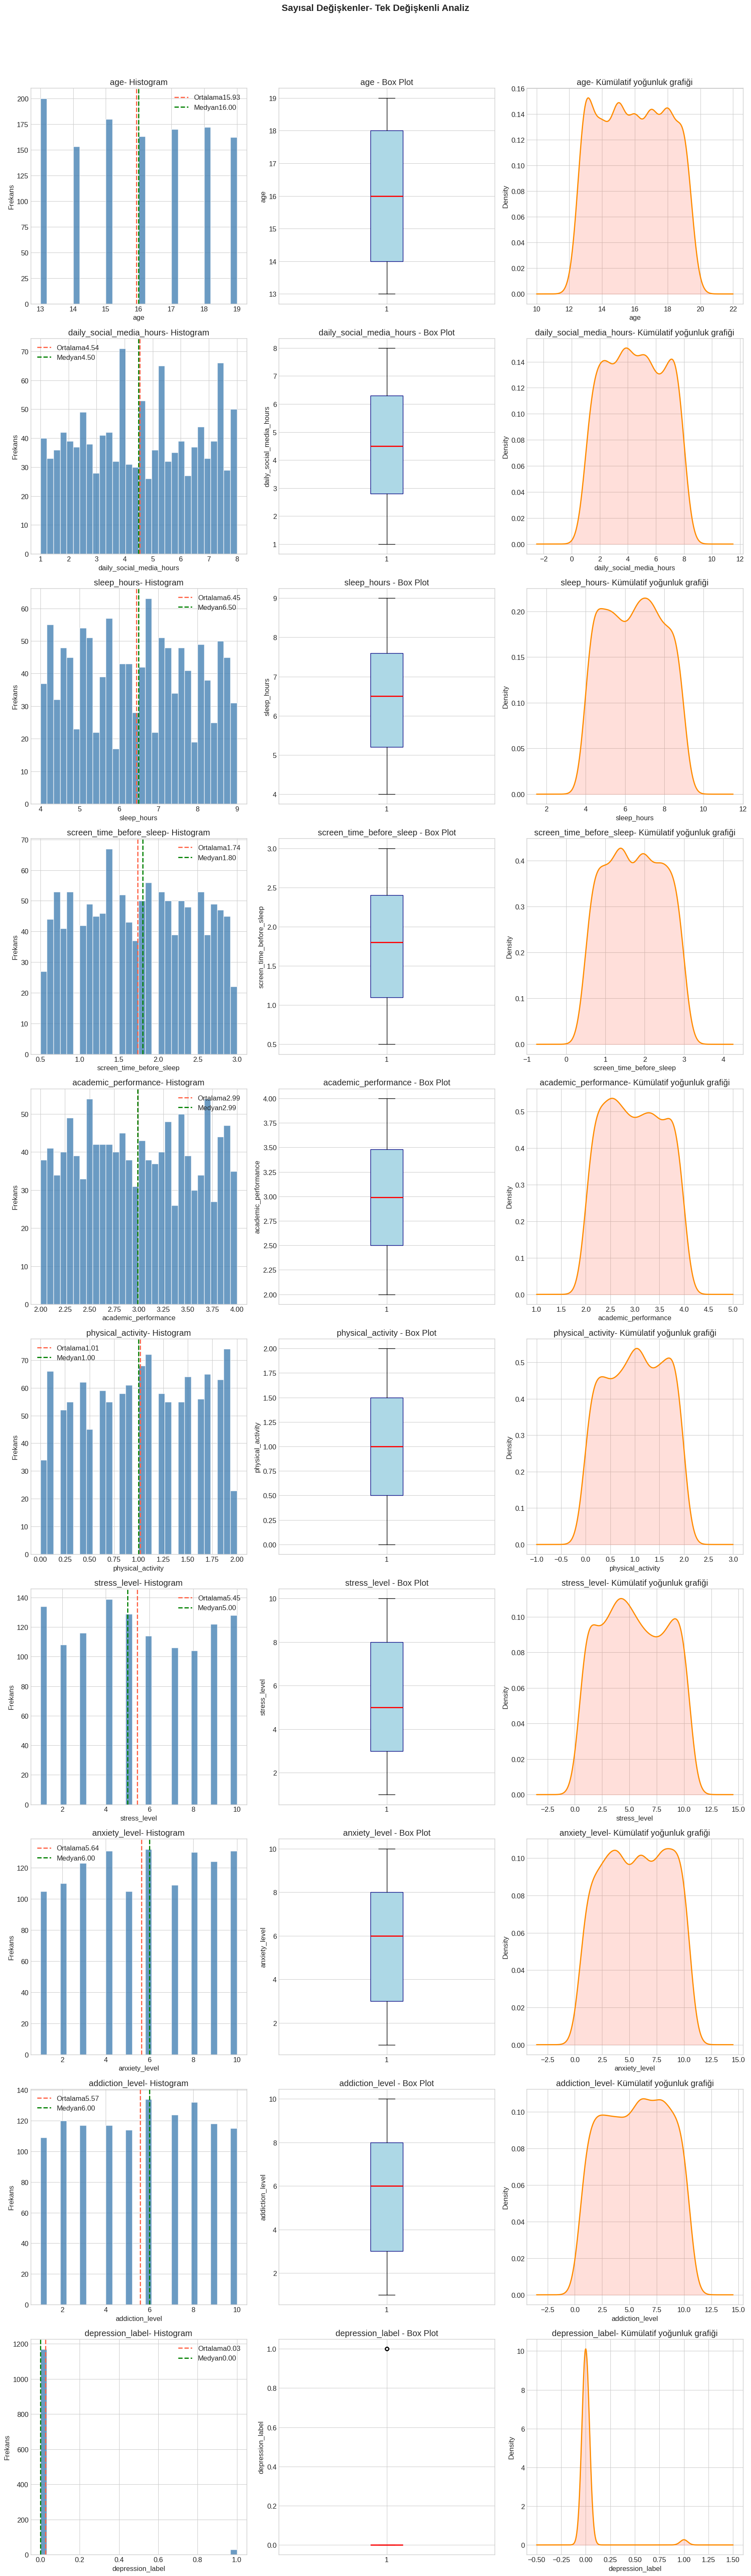

In [22]:
# sayısal değişkenler
sayisal_kolonlar = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3 , figsize=(18, 6*len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
    veri = df_new[kolon].dropna()

    axes[i,0].hist(veri, bins=30, color="steelblue",edgecolor='white',alpha=0.8)
    axes[i,0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama{veri.mean():.2f}')
    axes[i,0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan{veri.median():.2f}')
    axes[i,0].set_title(f'{kolon}- Histogram')
    axes[i,0].legend()
    axes[i,0].set_xlabel(kolon)
    axes[i,0].set_ylabel('Frekans')

    # Box plot
    axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{kolon} - Box Plot')
    axes[i, 1].set_ylabel(kolon)

    veri.plot.kde(ax=axes[i,2],color='darkorange',linewidth=2)
    axes[i,2].fill_between(axes[i,2].lines[0].get_xdata(),
                           axes[i,2].lines[0].get_ydata(),
                           color='tomato',alpha=0.2)
    axes[i,2].set_title(f'{kolon}- Kümülatif yoğunluk grafiği')
    axes[i,2].set_xlabel(kolon)

plt.suptitle('Sayısal Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# istatiksel özet tablo
print('Sayısal Değişkenler detaylı İstatistikler:')
print('='*70)


for kolon in sayisal_kolonlar :
  veri=df_new[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)

Sayısal Değişkenler detaylı İstatistikler:

 * AGE
Ortalama: 15.93
Medyan: 16.00
Standart Sapma: 2.02
Minimum: 13.00
Maksimum: 19.00
Varyans: 4.09
Skewness(Çarpıklık): 0.02
Kurtosis(Basıklık): -1.26
IQR: 4.00

 * DAILY_SOCIAL_MEDIA_HOURS
Ortalama: 4.54
Medyan: 4.50
Standart Sapma: 2.03
Minimum: 1.00
Maksimum: 8.00
Varyans: 4.12
Skewness(Çarpıklık): 0.01
Kurtosis(Basıklık): -1.19
IQR: 3.50

 * SLEEP_HOURS
Ortalama: 6.45
Medyan: 6.50
Standart Sapma: 1.44
Minimum: 4.00
Maksimum: 9.00
Varyans: 2.08
Skewness(Çarpıklık): 0.02
Kurtosis(Basıklık): -1.19
IQR: 2.40

 * SCREEN_TIME_BEFORE_SLEEP
Ortalama: 1.74
Medyan: 1.80
Standart Sapma: 0.72
Minimum: 0.50
Maksimum: 3.00
Varyans: 0.51
Skewness(Çarpıklık): 0.01
Kurtosis(Basıklık): -1.17
IQR: 1.30

 * ACADEMIC_PERFORMANCE
Ortalama: 2.99
Medyan: 2.99
Standart Sapma: 0.58
Minimum: 2.00
Maksimum: 4.00
Varyans: 0.33
Skewness(Çarpıklık): 0.04
Kurtosis(Basıklık): -1.21
IQR: 0.98

 * PHYSICAL_ACTIVITY
Ortalama: 1.01
Medyan: 1.00
Standart Sapma: 0.58
Minim

In [25]:
###Kategorik kolonlar

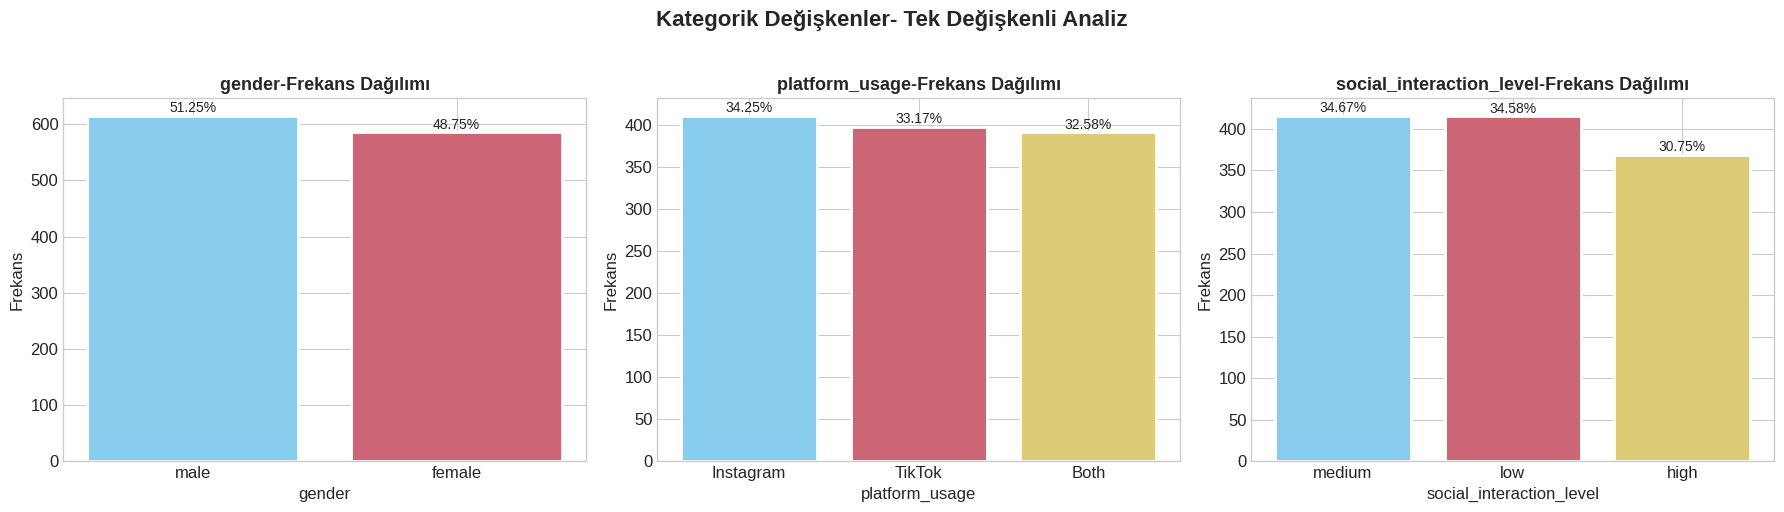

In [26]:
kategorik_kolonlar = ['gender', 'platform_usage', 'social_interaction_level']
fig,axes = plt.subplots(1,3,figsize=(18,5))
axes=axes.flatten()

renkler = ['#88CCEE', '#CC6677', '#DDCC77', '#117733', '#332288', '#AA4499']
for i,kolon in enumerate(kategorik_kolonlar):
    degerler=df_new[kolon].value_counts()
    yuzde = (degerler/len(df_new)*100).round(2)

    bars = axes[i].bar(degerler.index.astype(str),degerler.values,
                       color = renkler[:len(degerler)],edgecolor='white',linewidth=2)

    axes[i].set_title(f'{kolon}-Frekans Dağılımı',fontsize=13,fontweight='bold')
    axes[i].set_xlabel(kolon)
    axes[i].set_ylabel('Frekans')

    for bar ,pct in zip(bars,yuzde.values):
        axes[i].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+1,
                     f'{pct}%',
                     ha='center',
                     va='bottom',
                     fontsize=10)
plt.suptitle('Kategorik Değişkenler- Tek Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [46]:
print(df_new['depression_label'].value_counts())
print(df_new['stress_level'].dtype)

depression_label
0    1169
1      31
Name: count, dtype: int64
int64


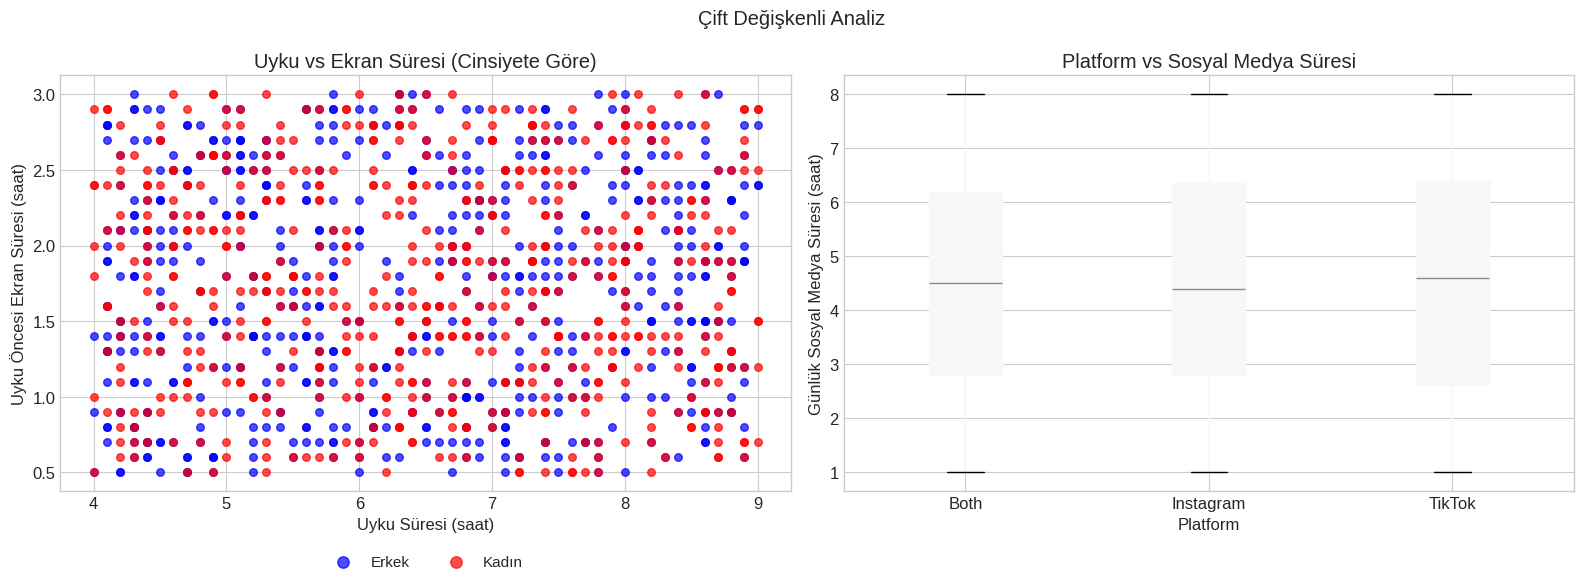

In [61]:
#sayısal vs Sayısal : Scatter Plot

fig,axes = plt.subplots(1,2,figsize=(16,6))

#sleep_hours vs screen_time_before_sleep
erkek = df_new[df_new['gender']=='male']
kadin = df_new[df_new['gender']=='female']

axes[0].scatter(erkek['sleep_hours'],erkek['screen_time_before_sleep'],color='blue',label='Erkek',alpha=0.7,s=30)
axes[0].scatter(kadin['sleep_hours'],kadin['screen_time_before_sleep'],color='red',label='Kadın',alpha=0.7,s=30)
axes[0].set_xlabel('Uyku Süresi (saat)')
axes[0].set_ylabel('Uyku Öncesi Ekran Süresi (saat)')
axes[0].set_title('Uyku vs Ekran Süresi (Cinsiyete Göre)')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
               ncol=2, framealpha=0.9, markerscale=1.5, fontsize=11)

#platform_usage vs daily_social_media_hours
df_new.boxplot(column='daily_social_media_hours',by='platform_usage',ax=axes[1],patch_artist=True)
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Günlük Sosyal Medya Süresi (saat)')
axes[1].set_title('Platform vs Sosyal Medya Süresi')

plt.suptitle('Çift Değişkenli Analiz')
plt.tight_layout()
plt.show()

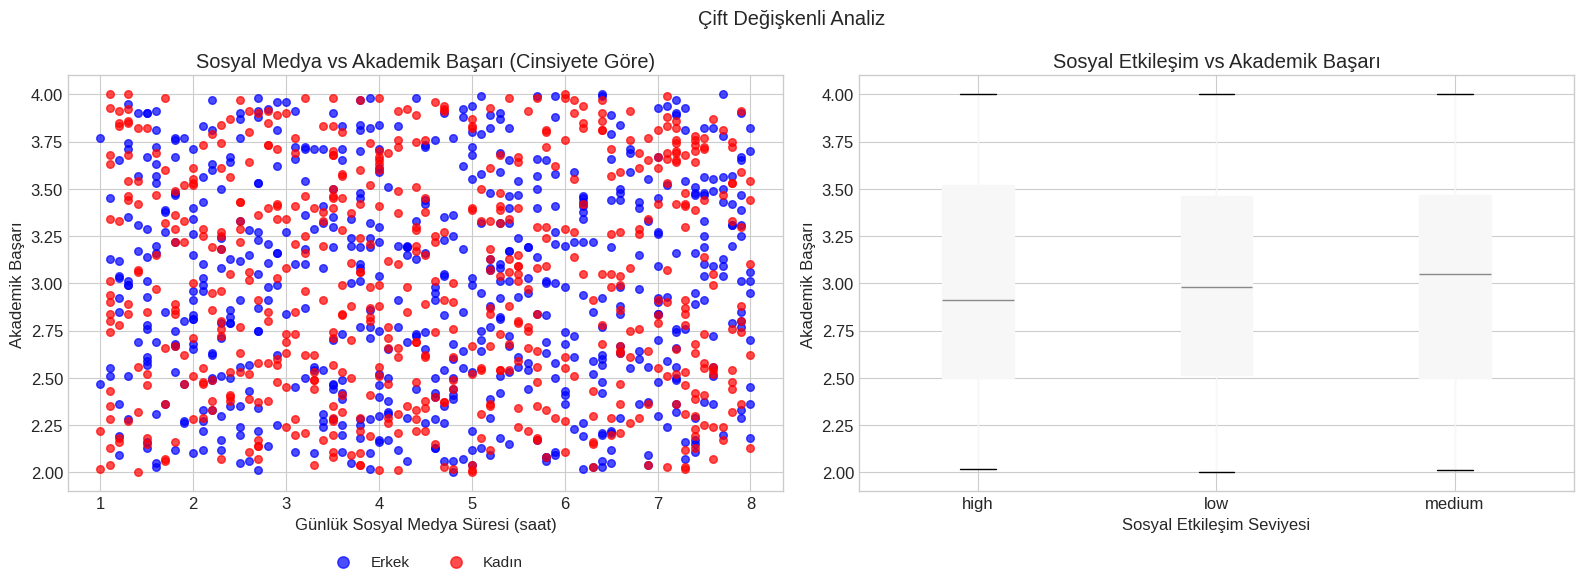

In [62]:
#sayısal vs Sayısal : Scatter Plot

fig,axes = plt.subplots(1,2,figsize=(16,6))

#daily_social_media_hours vs academic_performance
erkek = df_new[df_new['gender']=='male']
kadin = df_new[df_new['gender']=='female']

axes[0].scatter(erkek['daily_social_media_hours'],erkek['academic_performance'],color='blue',label='Erkek',alpha=0.7,s=30)
axes[0].scatter(kadin['daily_social_media_hours'],kadin['academic_performance'],color='red',label='Kadın',alpha=0.7,s=30)
axes[0].set_xlabel('Günlük Sosyal Medya Süresi (saat)')
axes[0].set_ylabel('Akademik Başarı')
axes[0].set_title('Sosyal Medya vs Akademik Başarı (Cinsiyete Göre)')
axes[0].legend(loc='upper center',bbox_to_anchor=(0.5,-0.12),ncol=2,framealpha=0.9,markerscale=1.5,fontsize=11)

#social_interaction_level vs academic_performance
df_new.boxplot(column='academic_performance',by='social_interaction_level',ax=axes[1],patch_artist=True)
axes[1].set_xlabel('Sosyal Etkileşim Seviyesi')
axes[1].set_ylabel('Akademik Başarı')
axes[1].set_title('Sosyal Etkileşim vs Akademik Başarı')

plt.suptitle('Çift Değişkenli Analiz')
plt.tight_layout()
plt.show()

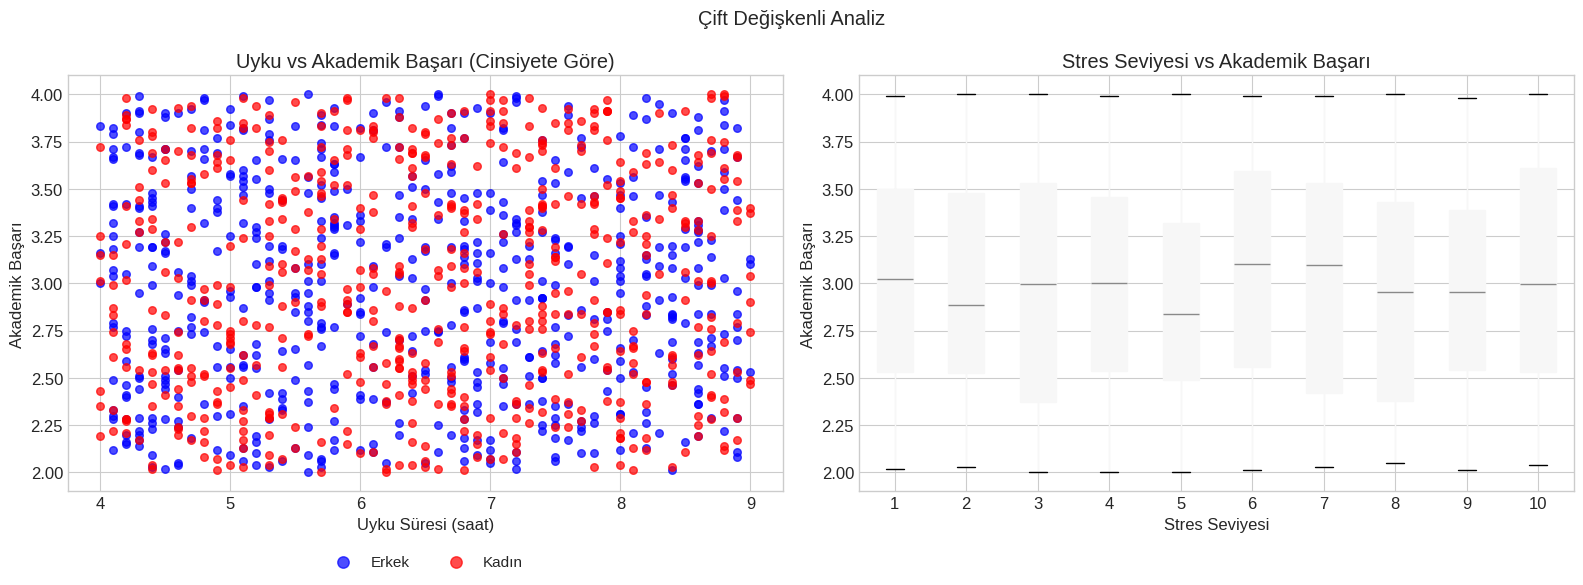

In [63]:
#sayısal vs Sayısal : Scatter Plot

fig,axes = plt.subplots(1,2,figsize=(16,6))

#sleep_hours vs academic_performance
erkek = df_new[df_new['gender']=='male']
kadin = df_new[df_new['gender']=='female']

axes[0].scatter(erkek['sleep_hours'],erkek['academic_performance'],color='blue',label='Erkek',alpha=0.7,s=30)
axes[0].scatter(kadin['sleep_hours'],kadin['academic_performance'],color='red',label='Kadın',alpha=0.7,s=30)
axes[0].set_xlabel('Uyku Süresi (saat)')
axes[0].set_ylabel('Akademik Başarı')
axes[0].set_title('Uyku vs Akademik Başarı (Cinsiyete Göre)')
axes[0].legend(loc='upper center',bbox_to_anchor=(0.5,-0.12),ncol=2,framealpha=0.9,markerscale=1.5,fontsize=11)

#stress_level vs academic_performance
df_new.boxplot(column='academic_performance',by='stress_level',ax=axes[1],patch_artist=True)
axes[1].set_xlabel('Stres Seviyesi')
axes[1].set_ylabel('Akademik Başarı')
axes[1].set_title('Stres Seviyesi vs Akademik Başarı')

plt.suptitle('Çift Değişkenli Analiz')
plt.tight_layout()
plt.show()

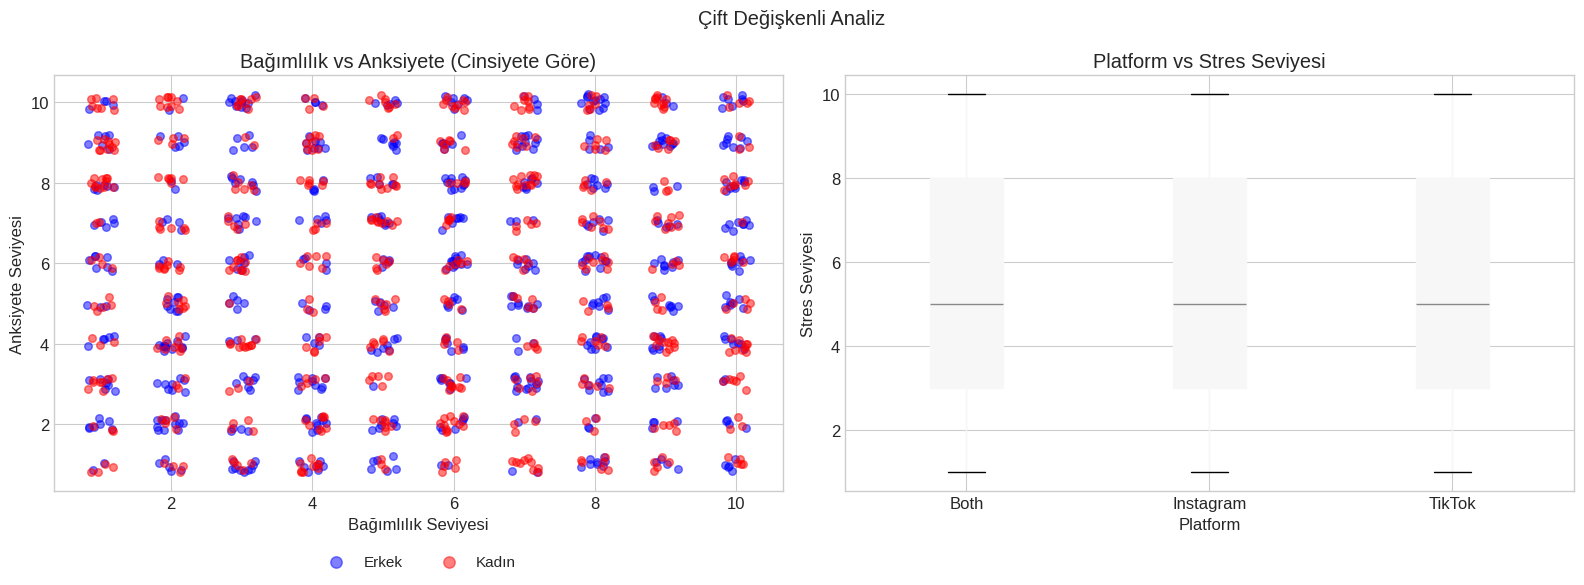

In [65]:


fig,axes = plt.subplots(1,2,figsize=(16,6))

erkek = df_new[df_new['gender']=='male']
kadin = df_new[df_new['gender']=='female']

axes[0].scatter(erkek['addiction_level']+np.random.uniform(-0.2,0.2,len(erkek)),
                erkek['anxiety_level']+np.random.uniform(-0.2,0.2,len(erkek)),
                color='blue',label='Erkek',alpha=0.5,s=30)
axes[0].scatter(kadin['addiction_level']+np.random.uniform(-0.2,0.2,len(kadin)),
                kadin['anxiety_level']+np.random.uniform(-0.2,0.2,len(kadin)),
                color='red',label='Kadın',alpha=0.5,s=30)
axes[0].set_xlabel('Bağımlılık Seviyesi')
axes[0].set_ylabel('Anksiyete Seviyesi')
axes[0].set_title('Bağımlılık vs Anksiyete (Cinsiyete Göre)')
axes[0].legend(loc='upper center',bbox_to_anchor=(0.5,-0.12),ncol=2,framealpha=0.9,markerscale=1.5,fontsize=11)

df_new.boxplot(column='stress_level',by='platform_usage',ax=axes[1],patch_artist=True)
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Stres Seviyesi')
axes[1].set_title('Platform vs Stres Seviyesi')

plt.suptitle('Çift Değişkenli Analiz')
plt.tight_layout()
plt.show()

In [79]:
tiktok = df_new[df_new['platform_usage']=='TikTok']

toplam_tiktok = len(tiktok)
tiktok_erkek = len(tiktok[tiktok['gender']=='male'])
tiktok_kadin = len(tiktok[tiktok['gender']=='female'])
print(toplam_tiktok)
print(tiktok_erkek)
print(tiktok_kadin)

398
205
193


In [73]:
df_new[df_new['platform_usage']=='TikTok']['gender'].value_counts()

,count
gender,
male,205
female,193


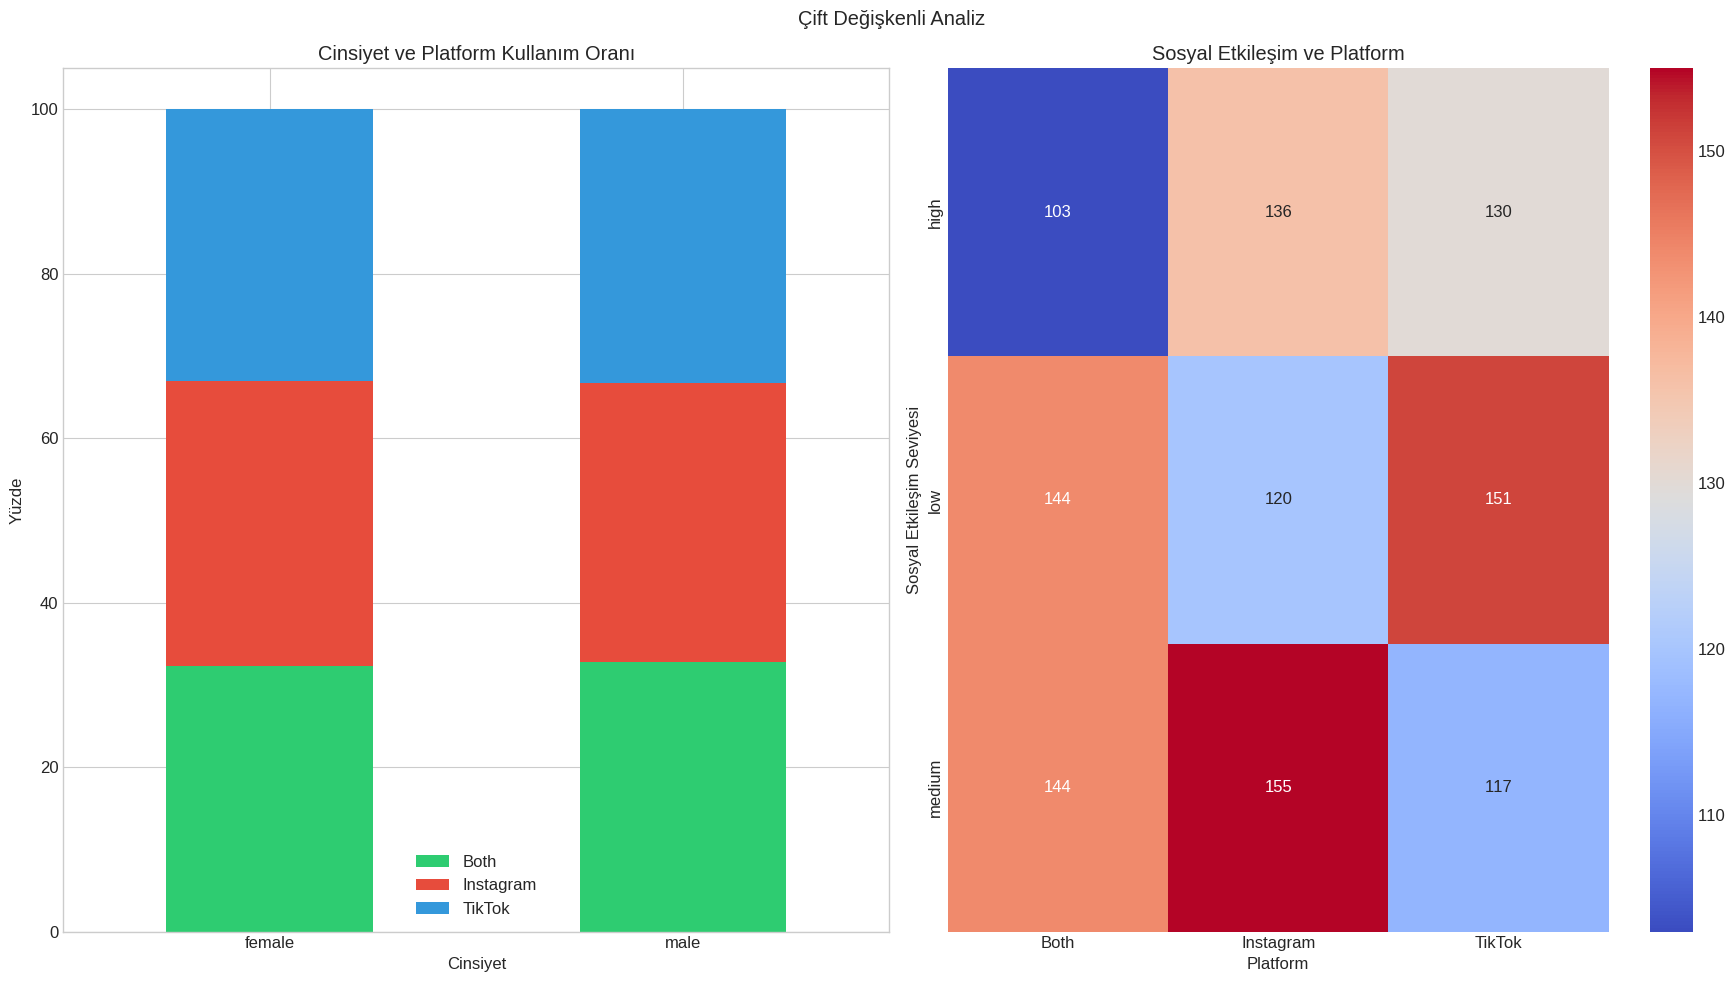

In [74]:
#Kategorik vs Kategorik

fig,axes = plt.subplots(1,2,figsize=(18,10))

ct_pct = pd.crosstab(df_new['gender'],df_new['platform_usage'],normalize='index')*100
ct_pct.plot(kind='bar',stacked=True,ax=axes[0],color=['#2ecc71','#e74c3c','#3498db'])
axes[0].set_title('Cinsiyet ve Platform Kullanım Oranı')
axes[0].set_xlabel('Cinsiyet')
axes[0].set_ylabel('Yüzde')
axes[0].legend(['Both','Instagram','TikTok'])
axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation=0)

ct2 = pd.crosstab(df_new['social_interaction_level'],df_new['platform_usage'])
sns.heatmap(ct2,annot=True,fmt='d',cmap='coolwarm',ax=axes[1])
axes[1].set_title('Sosyal Etkileşim ve Platform')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Sosyal Etkileşim Seviyesi')

plt.suptitle('Çift Değişkenli Analiz')
plt.tight_layout()
plt.show()

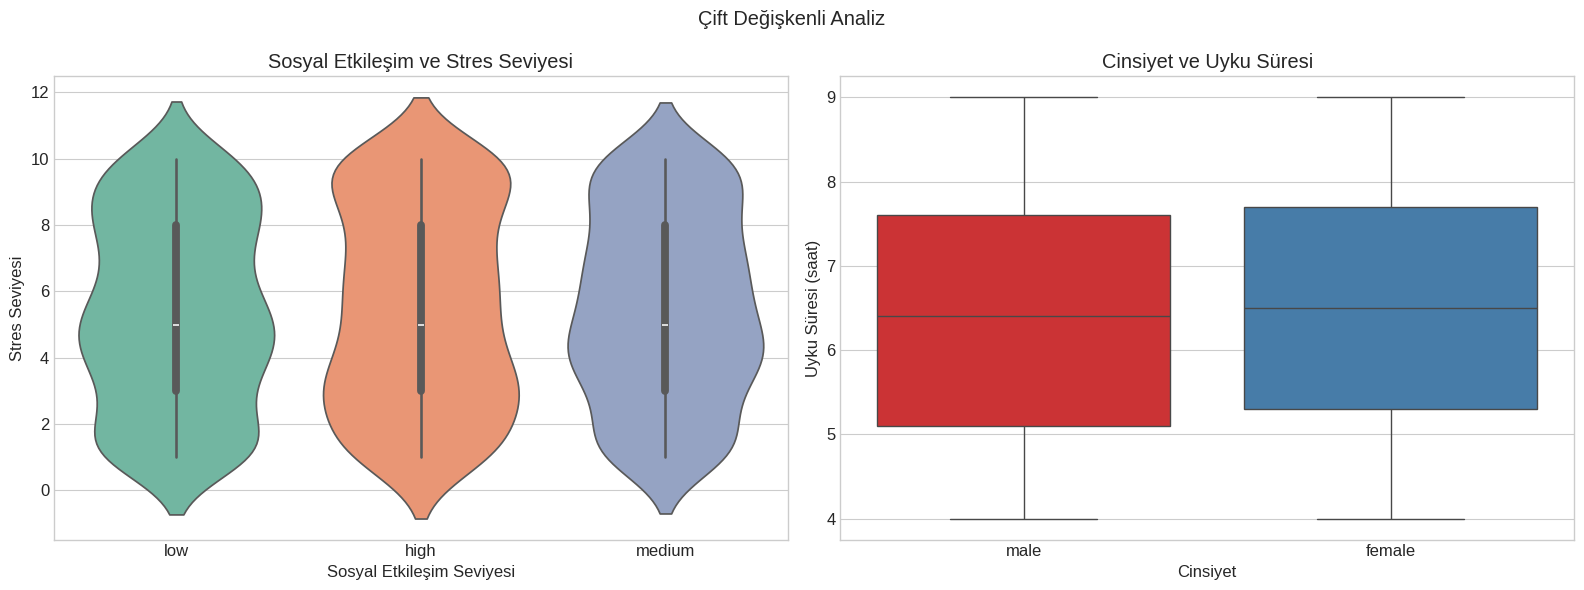

In [75]:
# kategorik vs sayısal

fig,axes = plt.subplots(1,2,figsize=(16,6))

sns.violinplot(data=df_new,x='social_interaction_level',y='stress_level',ax=axes[0],palette='Set2')
axes[0].set_title('Sosyal Etkileşim ve Stres Seviyesi')
axes[0].set_xlabel('Sosyal Etkileşim Seviyesi')
axes[0].set_ylabel('Stres Seviyesi')

sns.boxplot(data=df_new,x='gender',y='sleep_hours',ax=axes[1],palette='Set1')
axes[1].set_title('Cinsiyet ve Uyku Süresi')
axes[1].set_xlabel('Cinsiyet')
axes[1].set_ylabel('Uyku Süresi (saat)')

plt.suptitle('Çift Değişkenli Analiz')
plt.tight_layout()
plt.show()